## Read PCAP File and CSV

In [9]:
from scapy.all import rdpcap
from pathlib import Path
from loguru import logger
from scapy.all import IP, TCP, Ether, raw, UDP, wrpcap
from scapy.utils import RawPcapReader


def stream_pcap(pcap_path):
    """Generator to yield parsed packets and their timestamps from a pcap file"""
    for pkt_data, pkt_metadata in RawPcapReader(pcap_path):
        pkt = Ether(pkt_data)
        ts = pkt_metadata.sec + pkt_metadata.usec / 1e6
        yield pkt, ts


# Load packets from a pcap file
file_path = Path(
    # r"E:\MSc Works\IDS\data\DNP3 PCAP Files\20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap"
    r"E:\MSc Works\IDS\data\DNP3 PCAP Files\20200519_Stop_Application_Attack_UOWM_DNP3_Dataset_Slave_01.pcap"
)
csv_dir = Path(r"E:\MSc Works\IDS\data\Custom_DNP3_Parser\45_timeout")
csv_path = (
    csv_dir
    / "20200515_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap45DNP3_FLOWLABELED.csv"
)
# all_packets = rdpcap(str(file_path))
all_packets = stream_pcap(str(file_path))

In [10]:
# sort packets by time
# all_packets.sort(key=lambda x: x.time)
all_packets = sorted(all_packets, key=lambda x: x[1])

In [22]:
all_packets[12][0].show()

###[ Ethernet ]###
  dst       = be:0a:53:64:d9:b4
  src       = be:0a:53:35:94:71
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 70
     id        = 3515
     flags     = DF
     frag      = 0
     ttl       = 64
     proto     = tcp
     chksum    = 0xa9a2
     src       = 192.168.1.1
     dst       = 192.168.1.3
     \options   \
###[ TCP ]###
        sport     = 53048
        dport     = 20001
        seq       = 522064466
        ack       = 2540142194
        dataofs   = 8
        reserved  = 0
        flags     = PA
        window    = 312
        chksum    = 0xab6
        urgptr    = 0
        options   = [('NOP', None), ('NOP', None), ('Timestamp', (19695320, 19691178))]
###[ Raw ]###
           load      = b'\x05d\x0b\xc4\x0b\x00\x02\x00\xef\xa3\xcc\xcb\x01<\x02\x06\xa5\x07'



In [23]:
import pandas as pd

csv_path = (
    csv_dir
    / "20200515_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap45DNP3_FLOWLABELED.csv"
)
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]  # strip whitespace from column names
# Convert ' date' column to utc datetime and then to timestamp in seconds
df["timestamp"] = pd.to_datetime(df["date"])
df = df.sort_values(by="timestamp", ascending=True)

df.head()

C:\Users\Viper\AppData\Local\Temp\ipykernel_6504\1888138407.py:10: UserWarning: Parsing dates in  %d/%m/%Y  %H:%M:%S  format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(df["date"])


,Unnamed: 0,flow ID,source IP,destination IP,source port,destination port,protocol,date,duration,TotalFwdPkts,...,firstPacketDIR,mostCommonREQ_FUNC_CODE,mostCommonRESP_FUNC_CODE,corruptConfigFragments,deviceTroubleFragments,deviceRestartFragments,pktsFromMASTER,pktsFromSLAVE,Label,timestamp
0,0,192.168.1.12-192.168.1.4-56526-20003,192.168.1.12,192.168.1.4,56526,20003,6,15/05/2020 18:20:01,44023499.0,24,...,MASTER,1,129,0,0,0,24,24,COLD_RESTART,2020-05-15 18:20:01
1,1,192.168.1.12-192.168.1.3-46578-20003,192.168.1.12,192.168.1.3,46578,20003,6,15/05/2020 18:20:01,44022985.0,24,...,MASTER,1,129,0,0,0,24,24,COLD_RESTART,2020-05-15 18:20:01
2,2,192.168.1.12-192.168.1.5-37363-20003,192.168.1.12,192.168.1.5,37363,20003,6,15/05/2020 18:20:01,44022904.0,24,...,MASTER,1,129,0,0,0,24,24,COLD_RESTART,2020-05-15 18:20:01
3,3,192.168.1.12-192.168.1.8-43941-20003,192.168.1.12,192.168.1.8,43941,20003,6,15/05/2020 18:20:01,44019871.0,24,...,MASTER,1,129,0,0,0,24,24,COLD_RESTART,2020-05-15 18:20:01
4,4,192.168.1.12-192.168.1.10-55149-20003,192.168.1.12,192.168.1.10,55149,20003,6,15/05/2020 18:20:01,44023988.0,24,...,MASTER,1,129,0,0,0,24,24,COLD_RESTART,2020-05-15 18:20:01


In [122]:
# pd.to_datetime(float(all_packets[0].time) * 10**9), pd.to_datetime(
#     float(all_packets[-1].time) * 10**9
# ), df["timestamp"].min(), df["timestamp"].max()
pd.to_datetime(float(all_packets[0][1]) * 10**9), pd.to_datetime(
    float(all_packets[-1][1]) * 10**9
), df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2020-05-15 15:20:01.575036160'),
 Timestamp('2020-05-15 19:19:59.448779008'),
 Timestamp('2020-05-15 18:20:01'),
 Timestamp('2020-05-15 22:19:22'))

It seems there is 3 hours delay in packet time than the df's time!

In [123]:
# pkt_time1 = pd.to_datetime(float(all_packets[0].time) * 10**9)
# pkt_time2 = pd.to_datetime(float(all_packets[-1].time) * 10**9)
pkt_time1 = pd.to_datetime(float(all_packets[0][1]) * 10**9)
pkt_time2 = pd.to_datetime(float(all_packets[-1][1]) * 10**9)
df_time1 = df["timestamp"].min()
df_time2 = df["timestamp"].max()

time_diff1 = df_time1 - pkt_time1
time_diff2 = df_time2 - pkt_time2
avg_diff = (time_diff1 + time_diff2) / 2

print(
    f"PKT time range: {pkt_time1} to {pkt_time2}\n"
    f"DFm time range: {df_time1} to {df_time2}"
)
print(f"Time difference for first packet: {time_diff1}")
print(f"Time difference for last packet: {time_diff2}")
print(f"Average time difference: {avg_diff}")

PKT time range: 2020-05-15 15:20:01.575036160 to 2020-05-15 19:19:59.448779008
DFm time range: 2020-05-15 18:20:01 to 2020-05-15 22:19:22
Time difference for first packet: 0 days 02:59:59.424963840
Time difference for last packet: 0 days 02:59:22.551220992
Average time difference: 0 days 02:59:40.988092416


Looks like ~3 hours should be subtracted from the DF.

In [124]:
len(all_packets), df["TotalBwdPkts"].sum() + df["TotalFwdPkts"].sum()

(127615, 127615)

Number of packets matches.

In [125]:
pd.Timedelta(microseconds=df["duration"].iloc[0])

Timedelta('0 days 00:00:44.023499')

In [126]:
pkt_time1 + pd.Timedelta(hours=3), pkt_time2 + avg_diff, df_time1, df_time2

(Timestamp('2020-05-15 18:20:01.575036160'),
 Timestamp('2020-05-15 22:19:40.436871424'),
 Timestamp('2020-05-15 18:20:01'),
 Timestamp('2020-05-15 22:19:22'))

In [128]:
# pkt_times = [pd.to_datetime(float(pkt.time) * 10**9).timestamp() for pkt in all_packets]
pkt_times = [pd.to_datetime(float(pkt[1]) * 10**9).timestamp() for pkt in all_packets]
pkt_idxs = list(range(len(all_packets)))

In [88]:
df.columns

Index(['Unnamed: 0', 'flow ID', 'source IP', 'destination IP', 'source port',
       'destination port', 'protocol', 'date', 'duration', 'TotalFwdPkts',
       ...
       'firstPacketDIR', 'mostCommonREQ_FUNC_CODE', 'mostCommonRESP_FUNC_CODE',
       'corruptConfigFragments', 'deviceTroubleFragments',
       'deviceRestartFragments', 'pktsFromMASTER', 'pktsFromSLAVE', 'Label',
       'timestamp'],
      dtype='object', length=103)

In [208]:
from scapy.all import IP, TCP, Ether, raw, UDP, wrpcap
from pathlib import Path
from tqdm import tqdm

labelled_sessions = []
file_path = Path(
    r"E:\MSc Works\IDS\data\DNP3 PCAP Files\20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap"
)
csv_path = (
    csv_dir
    / "20200515_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap45DNP3_FLOWLABELED.csv"
)
output_path = Path(r"E:\MSc Works\IDS\notebooks\dnp3_sessions")
pkt_idxs = list(range(len(all_packets)))

with open(output_path / "labelled_sessions.csv", "w") as f:
    # f.write(
    #     "flow_id,src_ip,dst_ip,src_port,dst_port,protocol,start_time,end_time,total_matched_pkts,total_labeled_pkts,matched_forward_pkts,matched_backward_pkts,labled_forward_pkts,labled_backward_pkts,session_file_name,flow_label\n"
    # )
    pass
pbar = tqdm(total=len(df), desc="Processing sessions", unit="session")
for sess_idx, row in df.iterrows():
    pbar.update(1)
    pbar.desc = f"{sess_idx + 1}/{len(df)}"
    start_dt = row["timestamp"] - pd.Timedelta(hours=3)
    end_dt = start_dt + pd.Timedelta(microseconds=df.iloc[0].duration, seconds=0.574)
    # convert to seconds
    start_sec = start_dt.timestamp()
    end_sec = end_dt.timestamp()
    total_fwd_pkts = row["TotalFwdPkts"]
    total_bwd_pkts = row["TotalBwdPkts"]
    labled_pkts = total_bwd_pkts + total_fwd_pkts
    matched_idxs = [idx for idx in pkt_idxs if start_sec <= pkt_times[idx] <= end_sec]
    idx_matched_pkts = [all_packets[idx] for idx in matched_idxs]

    src_ip = row["source IP"]
    dst_ip = row["destination IP"]
    src_port = row["source port"]
    dst_port = row["destination port"]
    protocol = row["protocol"]
    flow_label = row["Label"]

    matched_pkts = []
    first_pkt = None
    final_matched_idxs = []
    if idx_matched_pkts:
        for idx, pkt in zip(matched_idxs, idx_matched_pkts):
            pkt = pkt[0]  # Extract the packet from the tuple
            if not (pkt.haslayer(IP) and pkt.haslayer(Ether)):
                continue
            ip_layer = pkt.getlayer(IP) or pkt.getlayer("IPv6")
            if not ip_layer:
                continue
            if (ip_layer.src == src_ip and ip_layer.dst == dst_ip) or (
                ip_layer.src == dst_ip and ip_layer.dst == src_ip
            ):
                is_pkt_matched = False
                if pkt.haslayer(TCP):
                    if (pkt[TCP].sport == src_port and pkt[TCP].dport == dst_port) or (
                        pkt[TCP].sport == dst_port and pkt[TCP].dport == src_port
                    ):
                        is_pkt_matched = True
                elif pkt.haslayer(UDP):
                    if (
                        pkt.getlayer(UDP).sport == src_port
                        and pkt.getlayer(UDP).dport == dst_port
                    ) or (
                        pkt.getlayer(UDP).sport == dst_port
                        and pkt.getlayer(UDP).dport == src_port
                    ):
                        is_pkt_matched = True
                if is_pkt_matched:
                    matched_pkts.append(pkt)
                    final_matched_idxs.append(idx)
                    if not first_pkt:
                        first_pkt = pkt
        pbar.set_postfix(
            dict(
                matched_pkts=len(matched_pkts),
                total_pkts=labled_pkts,
                flow_label=flow_label,
            )
        )
    num_forward_pkts = len([pkt for pkt in matched_pkts if pkt.src == first_pkt.src])
    num_backward_pkts = len(matched_pkts) - num_forward_pkts
    part = csv_path.stem.split(".")[0]
    session_file_name = f"{flow_label}_{sess_idx}_{part}.pcap"
    labelled_sessions.append(
        {
            "flow_id": row["flow ID"],
            "src_ip": src_ip,
            "dst_ip": dst_ip,
            "src_port": src_port,
            "dst_port": dst_port,
            "protocol": protocol,
            "start_time": start_dt,
            "end_time": end_dt,
            "total_matched_pkts": len(matched_pkts),
            "total_labeled_pkts": labled_pkts,
            "matched_forward_pkts": num_forward_pkts,
            "matched_backward_pkts": num_backward_pkts,
            "labled_forward_pkts": total_fwd_pkts,
            "labled_backward_pkts": total_bwd_pkts,
            "session_file_name": session_file_name,
            "flow_label": flow_label,
            "input_file": file_path.name,
        }
    )
    # save session info to csv
    with open(output_path / "labelled_sessions.csv", "a") as f:
        if f.tell() == 0:  # write header if file is empty
            keys = [
                "flow_id",
                "src_ip",
                "dst_ip",
                "src_port",
                "dst_port",
                "protocol",
                "start_time",
                "end_time",
                "total_matched_pkts",
                "total_labeled_pkts",
                "matched_forward_pkts",
                "matched_backward_pkts",
                "labled_forward_pkts",
                "labled_backward_pkts",
                "session_file_name",
                "flow_label",
            ]
            f.write(",".join(keys) + "\n")
        # write session info
        f.write(",".join([str(labelled_sessions[-1][key]) for key in keys]) + "\n")

    # save session packets to a pcap file
    session_pcap_path = output_path / "sessions_pcap"
    if not session_pcap_path.exists():
        session_pcap_path.mkdir(parents=True, exist_ok=True)
    session_pcap_path = session_pcap_path / session_file_name
    if not matched_pkts:
        continue
    wrpcap(str(session_pcap_path), matched_pkts)
    for idx in final_matched_idxs:
        pkt_idxs.remove(idx)

    # break

2504/2504: 100%|██████████| 2504/2504 [00:59<00:00, 56.82session/s, matched_pkts=43, total_pkts=43, flow_label=COLD_RESTART]

In [209]:
# pkt = all_packets[pkt_idxs[1]]
pkt = all_packets[pkt_idxs[0]][0]
ip_layer = pkt.getlayer(IP) or pkt.getlayer("IPv6")

pkt_idxs[0], ip_layer, pd.to_datetime(float(all_packets[pkt_idxs[0]][1]) * 10**9)

(368,
 <IP  version=4 ihl=5 tos=0x0 len=70 id=1062 flags=DF frag=0 ttl=64 proto=tcp chksum=0xb32b src=192.168.1.12 dst=192.168.1.4 |<TCP  sport=56526 dport=20003 seq=2226643085 ack=3496506064 dataofs=8 reserved=0 flags=PA window=312 chksum=0x43b urgptr=0 options=[('NOP', None), ('NOP', None), ('Timestamp', (33088, 1488607))] |<Raw  load=b'\x05d\x0b\xc4\x0c\x00\x04\x00\xaaY\xe1\xc0\x01<\x02\x061\xa4' |>>>,
 Timestamp('2020-05-15 15:20:45.597692928'))

In [210]:
(
    df.iloc[0].timestamp
    - pd.Timedelta(hours=3)
    + pd.Timedelta(microseconds=df.iloc[0].duration, seconds=0.574)
)

Timestamp('2020-05-15 15:20:45.597499')

## Session CSV

In [1]:
# [pd.to_datetime(float(all_packets[pkt_idxs[i]][1]) * 10**9) for i in range(20)]

In [1]:
# read labelled sessions from csv
import pandas as pd
from pathlib import Path


output_path = Path(r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions")


labelled_sessions_df = pd.read_csv(output_path / "labelled_sessions.csv")
labelled_sessions_df

,flow_id,src_ip,dst_ip,src_port,dst_port,protocol,start_time,end_time,total_matched_pkts,total_labeled_pkts,matched_forward_pkts,matched_backward_pkts,labled_forward_pkts,labled_backward_pkts,raw_bytes_max_length,raw_bytes_min_length,raw_bytes_avg_length,session_file_name,flow_label,input_file
0,192.168.1.2-192.168.1.5-51789-20000,192.168.1.2,192.168.1.5,51789,20000,6,2020-05-18 15:35:01,2020-05-18 15:36:59.615660,29,30,29,0,16,14,100,83,84.137931,REPLAY_0_20200518_Replay_UOWM_DNP3_Dataset_Att...,REPLAY,20200518_Replay_UOWM_DNP3_Dataset_Attacker_03....
1,192.168.1.5-192.168.1.2-20000-51789,192.168.1.5,192.168.1.2,20000,51789,6,2020-05-18 15:37:01,2020-05-18 15:38:59.615660,19,20,19,0,12,8,730,83,132.368421,REPLAY_1_20200518_Replay_UOWM_DNP3_Dataset_Att...,REPLAY,20200518_Replay_UOWM_DNP3_Dataset_Attacker_03....
2,192.168.1.2-192.168.1.5-51789-20000,192.168.1.2,192.168.1.5,51789,20000,6,2020-05-18 15:40:01,2020-05-18 15:41:59.615660,5,5,5,0,4,1,93,83,87.400000,REPLAY_2_20200518_Replay_UOWM_DNP3_Dataset_Att...,REPLAY,20200518_Replay_UOWM_DNP3_Dataset_Attacker_03....
3,192.168.1.2-192.168.1.5-51789-20000,192.168.1.2,192.168.1.5,51789,20000,6,2020-05-18 15:42:05,2020-05-18 15:44:03.615660,9,10,9,0,7,3,358,83,136.000000,REPLAY_3_20200518_Replay_UOWM_DNP3_Dataset_Att...,REPLAY,20200518_Replay_UOWM_DNP3_Dataset_Attacker_03....
4,192.168.1.2-192.168.1.5-51789-20000,192.168.1.2,192.168.1.5,51789,20000,6,2020-05-18 15:44:11,2020-05-18 15:46:09.615660,7,7,7,0,3,4,358,83,187.428571,REPLAY_4_20200518_Replay_UOWM_DNP3_Dataset_Att...,REPLAY,20200518_Replay_UOWM_DNP3_Dataset_Attacker_03....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40415,192.168.1.1-192.168.1.10-36758-20001,192.168.1.1,192.168.1.10,36758,20001,6,2020-05-15 00:28:07,2020-05-15 00:30:05.626438,126,126,126,0,62,64,358,83,90.873016,DISABLE_UNSOLICITED_958_20200514_DNP3_Disable_...,DISABLE_UNSOLICITED,20200514_DNP3_Disable_Unsolicited_Messages_Att...
40416,192.168.1.1-192.168.1.4-37319-20001,192.168.1.1,192.168.1.4,37319,20001,6,2020-05-15 00:28:07,2020-05-15 00:30:05.626438,126,126,126,0,62,64,358,83,90.873016,DISABLE_UNSOLICITED_953_20200514_DNP3_Disable_...,DISABLE_UNSOLICITED,20200514_DNP3_Disable_Unsolicited_Messages_Att...
40417,192.168.1.1-192.168.1.3-45480-20001,192.168.1.1,192.168.1.3,45480,20001,6,2020-05-15 00:28:07,2020-05-15 00:30:05.626438,126,126,126,0,62,64,358,83,90.873016,DISABLE_UNSOLICITED_952_20200514_DNP3_Disable_...,DISABLE_UNSOLICITED,20200514_DNP3_Disable_Unsolicited_Messages_Att...
40418,192.168.1.1-192.168.1.7-43417-20001,192.168.1.1,192.168.1.7,43417,20001,6,2020-05-15 00:28:07,2020-05-15 00:30:05.626438,126,126,126,0,62,64,358,83,90.873016,DISABLE_UNSOLICITED_954_20200514_DNP3_Disable_...,DISABLE_UNSOLICITED,20200514_DNP3_Disable_Unsolicited_Messages_Att...


In [2]:
labelled_sessions_df.flow_label.value_counts()

flow_label
NORMAL                 14380
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
DNP3_ENUMERATE          3380
DNP3_INFO               3342
INIT_DATA                692
STOP_APP                 680
REPLAY                   666
Name: count, dtype: int64

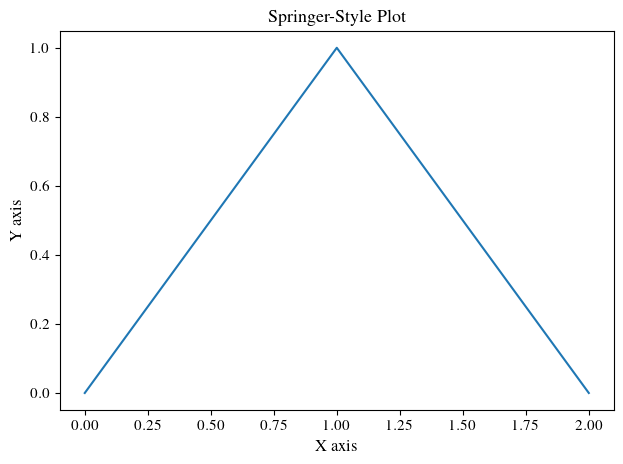

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font family and size
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif", "serif"]
mpl.rcParams["font.size"] = 12  # Adjust per Springer guidelines
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11

# Optional: PDF/LaTeX text rendering for enhanced output
mpl.rcParams["text.usetex"] = True  # Set to True only if you have a full LaTeX setup


C:\Users\Viper\AppData\Local\Temp\ipykernel_17416\3642173224.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Viper\AppData\Local\Temp\ipykernel_17416\3642173224.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Avg Labeled - Matched"], y=[avg_diff], palette="muted", ax=axes[1])
C:\Users\Viper\AppData\Local\Temp\ipykernel_17416\3642173224.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


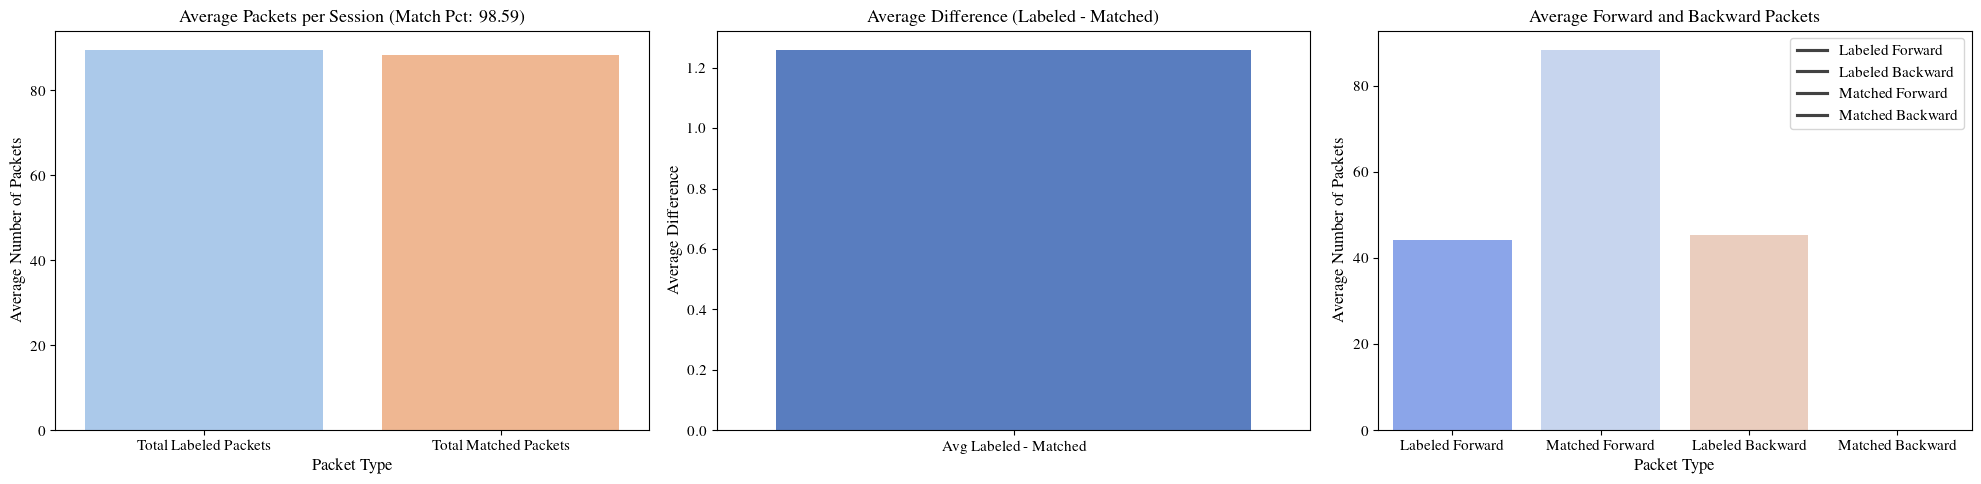

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate averages
avg_labeled = labelled_sessions_df["total_labeled_pkts"].mean()
avg_matched = labelled_sessions_df["total_matched_pkts"].mean()
avg_lbl_fwd = labelled_sessions_df["labled_forward_pkts"].mean()
avg_lbl_bwd = labelled_sessions_df["labled_backward_pkts"].mean()
avg_matched_fwd = labelled_sessions_df["matched_forward_pkts"].mean()
avg_matched_bwd = labelled_sessions_df["matched_backward_pkts"].mean()
rate = avg_matched / avg_labeled if avg_labeled else 0
avg_diff = avg_labeled - avg_matched

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# First subplot: averages
sns.barplot(
    x=["Total Labeled Packets", "Total Matched Packets"],
    y=[avg_labeled, avg_matched],
    palette="pastel",
    ax=axes[0],
)
axes[0].set_title(f"Average Packets per Session (Match Pct: {rate*100:.2f})")
axes[0].set_ylabel("Average Number of Packets")
axes[0].set_xlabel("Packet Type")

# Second subplot: difference
sns.barplot(x=["Avg Labeled - Matched"], y=[avg_diff], palette="muted", ax=axes[1])
axes[1].set_title("Average Difference (Labeled - Matched)")
axes[1].set_ylabel("Average Difference")
axes[1].set_xlabel("")

# Third subplot: forward and backward packets
sns.barplot(
    x=["Labeled Forward", "Matched Forward", "Labeled Backward", "Matched Backward"],
    y=[avg_lbl_fwd, avg_matched_fwd, avg_lbl_bwd, avg_matched_bwd],
    palette="coolwarm",
    ax=axes[2],
)
axes[2].set_title("Average Forward and Backward Packets")
axes[2].set_ylabel("Average Number of Packets")
axes[2].set_xlabel("Packet Type")
axes[2].legend(
    ["Labeled Forward", "Labeled Backward", "Matched Forward", "Matched Backward"]
)
# rotate


plt.tight_layout()
plt.show()

In [5]:
# start_sec, end_sec, pkt_times[0], pkt_times[-1]
# start_sec - pkt_times[0], end_sec - pkt_times[-1]

In [6]:
# start_dt, end_dt

### Sample Session Images

In [37]:
from ids_expt.data.session_image_dataset import (
    DFDataSet,
    SessionImageDataConfig,
    SamplingMethod,
    TorchImageDataset,
)
from pathlib import Path
from loguru import logger

if __name__ == "__main__":
    df_ds = DFDataSet(
        SessionImageDataConfig(
            session_images_dir=Path(
                r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\session_images"
            ),
            labels_file=Path(
                r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\labelled_sessions.csv"
            ),
            train_ratio=0.75,
            random_seed=42,
            labels=["NORMAL", "ATTACK"],
            normal_label="NORMAL",
            combine_attacks=False,
            max_data=-1000,
            byte_length=8 * 32,
            num_pkts=6 * 32,
            sampling_method=SamplingMethod.NONE,
            use_normalized=False,
            min_num_pkts=1,
        )
    )
    train_ds, test_ds = df_ds.load_data()
    train_torch_ds = TorchImageDataset(train_ds)
    test_torch_ds = TorchImageDataset(test_ds)
    logger.info(f"Train dataset size: {len(train_torch_ds)}")
    logger.info(f"Test dataset size: {len(test_torch_ds)}")
    logger.info(f"Class weights: {train_torch_ds.class_weights}")
    logger.info(f"Label counts: {train_torch_ds.label_counts}")

2025-07-14 23:38:11.584 | INFO     | ids_expt.data.session_image_dataset:load_data:137 - Data loaded into DataFrame with 38508 entries
2025-07-14 23:38:11.584 | INFO     | ids_expt.data.session_image_dataset:load_data:138 - Label distribution:
label
NORMAL                 14141
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
DNP3_ENUMERATE          2659
DNP3_INFO               2390
INIT_DATA                692
STOP_APP                 680
REPLAY                   666
Name: count, dtype: int64
2025-07-14 23:38:11.584 | INFO     | ids_expt.data.session_image_dataset:load_data:164 - Final dataset size: 38508 entries after applying max_data limit
2025-07-14 23:38:11.584 | INFO     | ids_expt.data.session_image_dataset:load_data:176 - Using labels: ['REPLAY', 'DNP3_INFO', 'DNP3_ENUMERATE', 'STOP_APP', 'NORMAL', 'INIT_DATA', 'COLD_RESTART', 'WARM_RESTART', 'DISABLE_UNSOLICITED']
2025-07-14 23:38:11.633 | INFO     | ids_expt.data.session_image_dataset:lo

### Visualize Counts

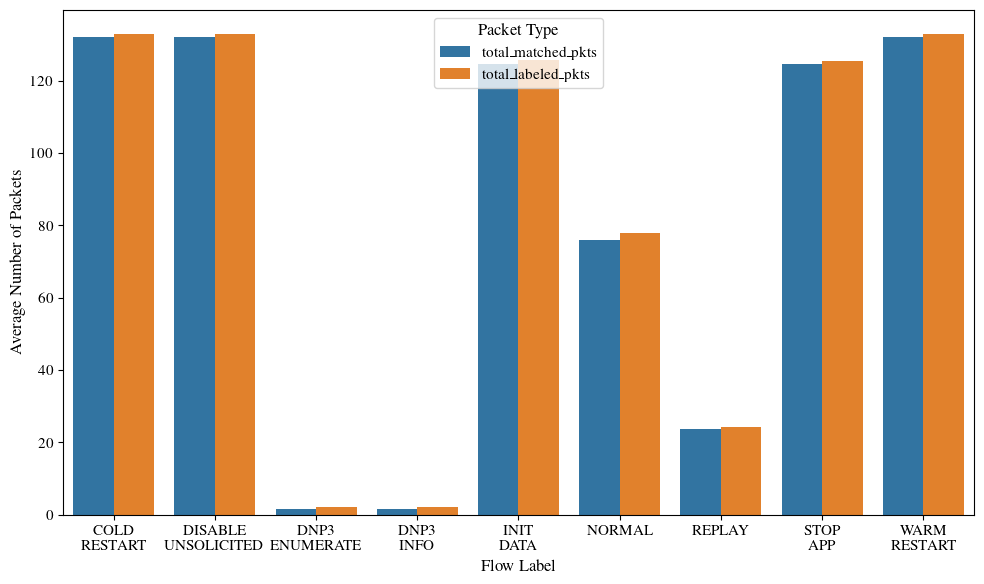

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

labels_file = Path(
    r"C:\Users\Viper\Desktop\thesis_code\data\120_timeout_dnp3_sessions\labelled_sessions.csv"
)
data_df = pd.read_csv(labels_file)

# Group by 'flow_label' and calculate means
mean_matched = data_df.groupby("flow_label")["total_matched_pkts"].mean()
mean_labeled = data_df.groupby("flow_label")["total_labeled_pkts"].mean()

# Combine into a single DataFrame for plotting
plot_df = pd.DataFrame(
    {"total_matched_pkts": mean_matched, "total_labeled_pkts": mean_labeled}
).reset_index()

# Melt DataFrame for seaborn
melted_df = plot_df.melt(
    id_vars="flow_label", var_name="Packet Type", value_name="Average Packets"
)

# Plot grouped bar plot
wrapped_labels = [
    "\n".join(label.split("_")) for label in melted_df["flow_label"].unique()
]
fig = plt.figure(figsize=(10, 6))
sns.barplot(x="flow_label", y="Average Packets", hue="Packet Type", data=melted_df)
plt.xlabel("Flow Label")
plt.ylabel("Average Number of Packets")
# plt.title("Average Total Matched vs Labeled Packets by Flow Label")
plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels)


plt.legend(title="Packet Type")
plt.tight_layout()
plt.savefig("avg_matched_vs_labeled_packets.pdf")
plt.show()

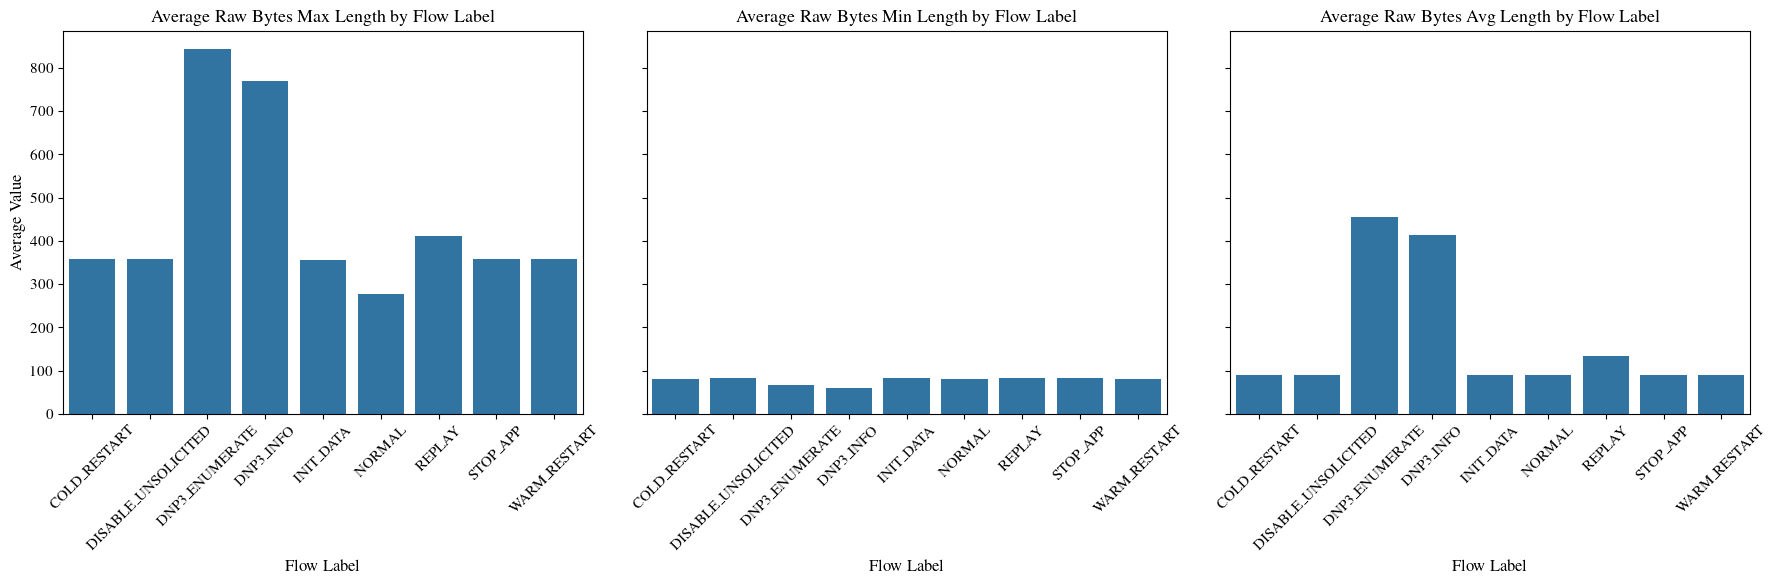

In [29]:
metrics = ["raw_bytes_max_length", "raw_bytes_min_length", "raw_bytes_avg_length"]
titles = [
    "Average Raw Bytes Max Length by Flow Label",
    "Average Raw Bytes Min Length by Flow Label",
    "Average Raw Bytes Avg Length by Flow Label",
]
mean_raw_bytes = (
    data_df.groupby("flow_label")[
        ["raw_bytes_max_length", "raw_bytes_min_length", "raw_bytes_avg_length"]
    ]
    .mean()
    .reset_index()
)
melted_df = mean_raw_bytes.melt(
    id_vars="flow_label", var_name="Metric", value_name="Average Value"
)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.barplot(
        x="flow_label",
        y="Average Value",
        data=melted_df[melted_df["Metric"] == metric],
        ax=axes[i],
    )
    axes[i].set_title(title)
    axes[i].set_xlabel("Flow Label")
    if i == 0:
        axes[i].set_ylabel("Average Value")
    else:
        axes[i].set_ylabel("")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

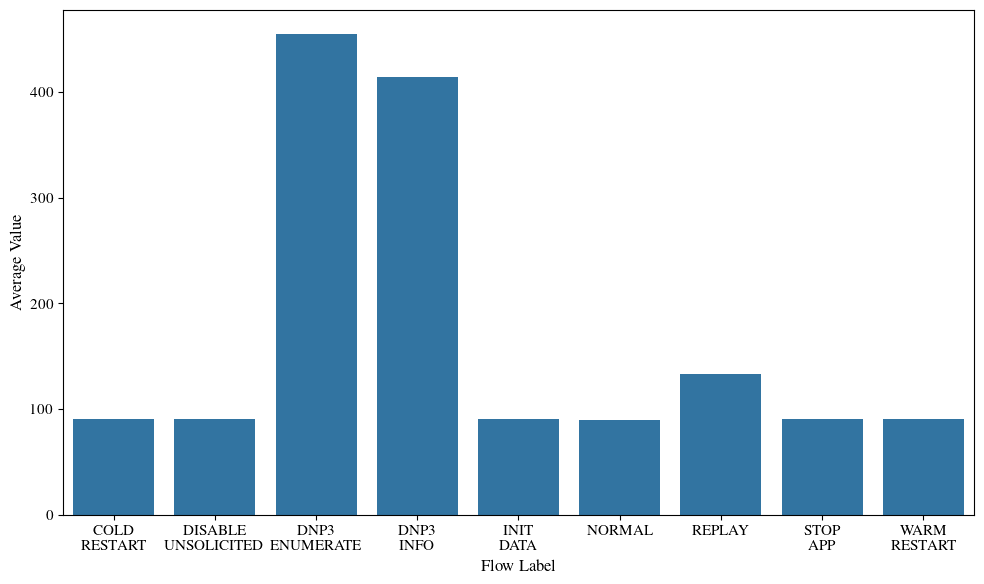

In [31]:
title = "Average of Average byte length of raw bytes by flow label"
mean_raw_bytes = (
    data_df.groupby("flow_label")[["raw_bytes_avg_length"]].mean().reset_index()
)
melted_df = mean_raw_bytes.melt(
    id_vars="flow_label", var_name="Metric", value_name="Average Value"
)
fig = plt.figure(figsize=(10, 6))
sns.barplot(
    x="flow_label",
    y="Average Value",
    data=melted_df[melted_df["Metric"] == "raw_bytes_avg_length"],
)
warped_labels = [
    "\n".join(label.split("_")) for label in melted_df["flow_label"].unique()
]
# plt.title(title)
plt.xlabel("Flow Label")
plt.ylabel("Average Value")
plt.xticks(ticks=range(len(warped_labels)), labels=warped_labels)
plt.tight_layout()
plt.savefig(r"avg_raw_bytes_avg_length.pdf")
plt.show()

### To Find Best Num. Pkts. and Pkt. Length

In [14]:
data_df.groupby("flow_label").total_matched_pkts.describe()

,count,mean,std,min,25%,50%,75%,max
flow_label,,,,,,,,
COLD_RESTART,5760.0,132.062674,1.777636,119.0,132.0,132.0,134.00,136.0
DISABLE_UNSOLICITED,5760.0,132.232639,1.654277,124.0,132.0,132.0,134.00,138.0
DNP3_ENUMERATE,3380.0,1.570710,0.819650,0.0,2.0,2.0,2.00,2.0
DNP3_INFO,3342.0,1.430281,0.902830,0.0,0.0,2.0,2.00,2.0
INIT_DATA,692.0,124.606936,3.122461,90.0,124.0,125.0,126.00,128.0
NORMAL,14380.0,75.884701,50.198328,0.0,27.0,124.0,126.00,126.0
REPLAY,666.0,23.665165,17.931882,2.0,11.0,17.0,30.75,94.0
STOP_APP,680.0,124.600000,4.249439,70.0,124.0,125.0,126.00,128.0
WARM_RESTART,5760.0,132.046354,1.648618,122.0,130.0,132.0,134.00,136.0


In [16]:
data_df.groupby("flow_label").raw_bytes_avg_length.describe()

,count,mean,std,min,25%,50%,75%,max
flow_label,,,,,,,,
COLD_RESTART,5760.0,90.267422,0.171885,87.165289,90.164179,90.287879,90.287879,90.991667
DISABLE_UNSOLICITED,5760.0,90.503304,0.071876,90.275362,90.432836,90.492424,90.537879,90.943548
DNP3_ENUMERATE,3380.0,454.856509,238.269217,0.000000,579.500000,579.500000,579.500000,1076.000000
DNP3_INFO,3342.0,414.423998,261.594979,0.000000,0.000000,579.500000,579.500000,579.500000
INIT_DATA,692.0,90.355315,1.216598,83.645161,90.682540,90.690476,90.798387,93.555556
NORMAL,14380.0,89.611551,15.560327,0.000000,83.392857,90.682540,90.798387,252.111111
REPLAY,666.0,133.309945,42.402292,83.200000,100.658869,124.425000,159.125000,296.555556
STOP_APP,680.0,90.326465,1.277562,83.645161,90.682540,90.682540,90.798387,96.428571
WARM_RESTART,5760.0,90.275990,0.095108,90.044118,90.164179,90.287879,90.392308,90.844262


In [38]:
import cv2

labels = train_ds.data_df.label.unique()
images = []
for label in labels:
    label_df = train_ds.data_df[train_ds.data_df.label == label]
    if not label_df.empty:
        images.append(cv2.imread(str(label_df.file_path.iloc[0])))

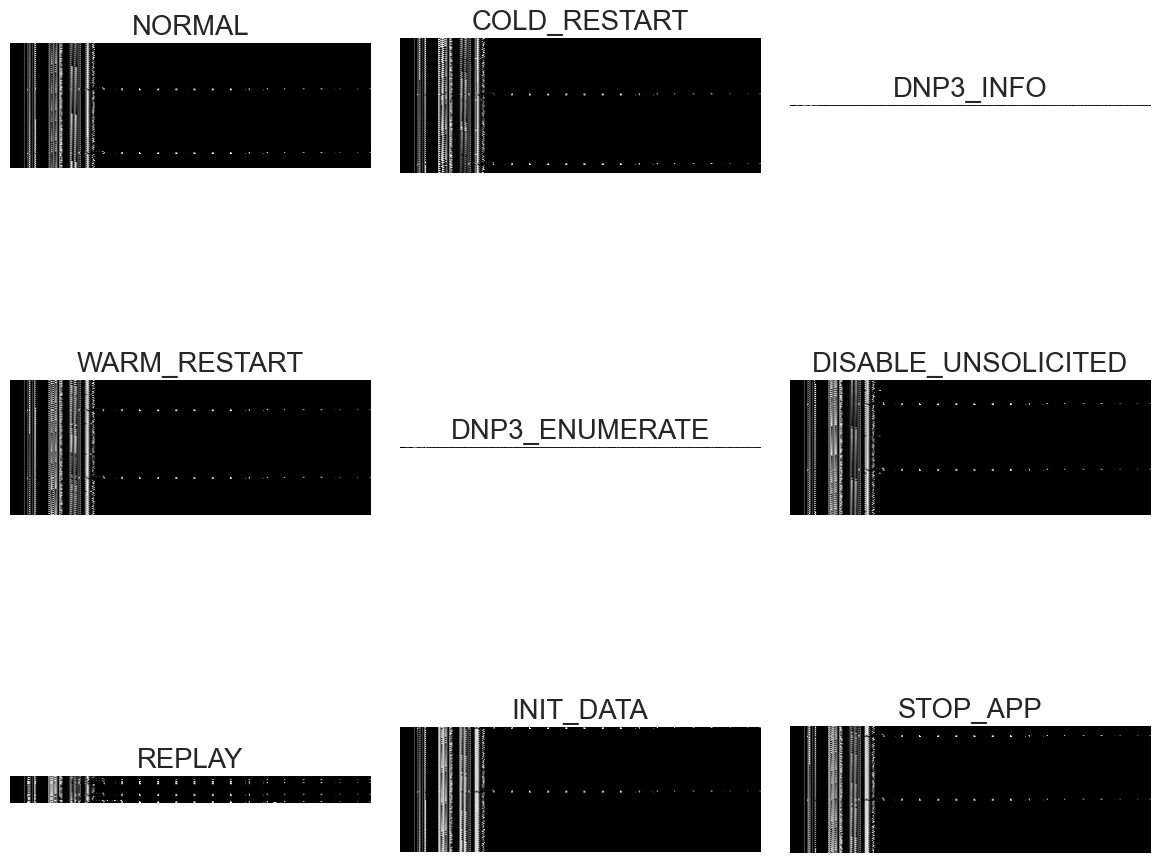

In [44]:
import matplotlib.pyplot as plt

n_images = len(images)
nrows = 3
ncols = (n_images + nrows - 1) // nrows  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten() if n_images > 1 else [axes]

for i, ax in enumerate(axes):
    if i < n_images:
        ax.imshow(images[i], cmap="gray")
        ax.set_title(f"{labels[i]}")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.savefig(r"sample_session_images.pdf")
plt.show()

### Sample Normalized Images

2025-07-14 23:37:46.243 | INFO     | ids_expt.data.session_image_dataset:load_data:115 - Using normalized images for training
2025-07-14 23:37:46.782 | INFO     | ids_expt.data.session_image_dataset:load_data:137 - Data loaded into DataFrame with 38508 entries
2025-07-14 23:37:46.802 | INFO     | ids_expt.data.session_image_dataset:load_data:138 - Label distribution:
label
NORMAL                 14141
COLD_RESTART            5760
WARM_RESTART            5760
DISABLE_UNSOLICITED     5760
DNP3_ENUMERATE          2659
DNP3_INFO               2390
INIT_DATA                692
STOP_APP                 680
REPLAY                   666
Name: count, dtype: int64
2025-07-14 23:37:46.803 | INFO     | ids_expt.data.session_image_dataset:load_data:164 - Final dataset size: 38508 entries after applying max_data limit
2025-07-14 23:37:46.803 | INFO     | ids_expt.data.session_image_dataset:load_data:176 - Using labels: ['REPLAY', 'DNP3_INFO', 'DNP3_ENUMERATE', 'STOP_APP', 'NORMAL', 'INIT_DATA', 'COL

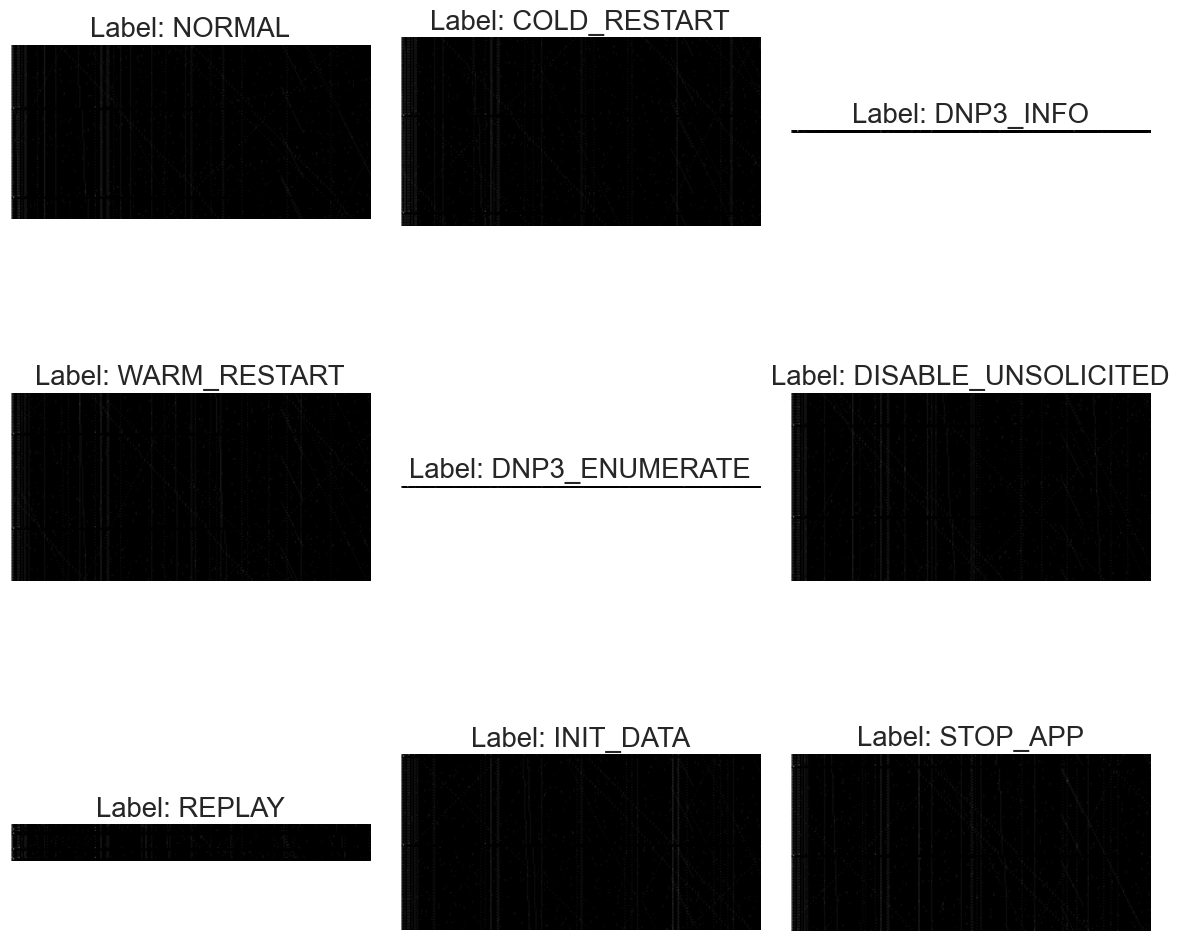

In [34]:
from ids_expt.data.session_image_dataset import (
    DFDataSet,
    SessionImageDataConfig,
    SamplingMethod,
    TorchImageDataset,
)
from pathlib import Path
from loguru import logger

if __name__ == "__main__":
    df_ds = DFDataSet(
        SessionImageDataConfig(
            session_images_dir=Path(
                r"E:\MSc Works\IDS\notebooks\120_timeout_dnp3_sessions\session_images"
            ),
            labels_file=Path(
                r"E:\MSc Works\IDS\notebooks\120_timeout_dnp3_sessions\labelled_sessions.csv"
            ),
            train_ratio=0.75,
            random_seed=42,
            labels=["NORMAL", "ATTACK"],
            normal_label="NORMAL",
            combine_attacks=False,
            max_data=-1000,
            byte_length=8 * 32,
            num_pkts=6 * 32,
            sampling_method=SamplingMethod.NONE,
            use_normalized=True,
            min_num_pkts=1,
        )
    )
    train_ds, test_ds = df_ds.load_data()
    train_torch_ds = TorchImageDataset(train_ds)
    test_torch_ds = TorchImageDataset(test_ds)
    logger.info(f"Train dataset size: {len(train_torch_ds)}")
    logger.info(f"Test dataset size: {len(test_torch_ds)}")
    logger.info(f"Class weights: {train_torch_ds.class_weights}")
    logger.info(f"Label counts: {train_torch_ds.label_counts}")


labels = train_ds.data_df.label.unique()
images = []
for label in labels:
    label_df = train_ds.data_df[train_ds.data_df.label == label]
    if not label_df.empty:
        images.append(cv2.imread(str(label_df.file_path.iloc[0])))


n_images = len(images)
nrows = 3
ncols = (n_images + nrows - 1) // nrows  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten() if n_images > 1 else [axes]

for i, ax in enumerate(axes):
    if i < n_images:
        ax.imshow(images[i], cmap="gray")
        ax.set_title(f"Label: {labels[i]}")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.savefig(r"sample_images_normalized.pdf")
plt.show()

## Extractor Class

In [230]:
import matplotlib.pyplot as plt


def plot_grayscale_array(array):
    """Plot a grayscale image from a 2D numpy array"""

    plt.imshow(array, cmap="gray", aspect="auto")

    plt.show()

In [285]:
from pathlib import Path
from loguru import logger
from dataclasses import dataclass
from scapy.all import Packet
import numpy as np
from scapy.all import IP, TCP, Ether, raw
import cv2
import json
from tqdm import tqdm
from scapy.utils import RawPcapReader
import pandas as pd
from scapy.layers.inet import IP, TCP, UDP, Ether
import pickle


def stream_pcap(pcap_path):
    """Generator to yield parsed packets and their timestamps from a pcap file"""
    for pkt_data, pkt_metadata in RawPcapReader(pcap_path):
        pkt = Ether(pkt_data)
        ts = pkt_metadata.sec + pkt_metadata.usec / 1e6
        yield pkt, ts


def is_dnp3_packet(pkt):
    # Check if packet has TCP or UDP layer
    if pkt.haslayer(TCP):
        l4 = pkt[TCP]
    elif pkt.haslayer(UDP):
        l4 = pkt[UDP]
    else:
        return False

    # Check if either src or dst port is 20000 (DNP3 default port)
    if l4.sport != 20000 and l4.dport != 20000:
        return False

    # Check if payload exists and starts with DNP3 header bytes 0x05 0x64
    raw = bytes(l4.payload)
    if len(raw) >= 2 and raw[0] == 0x05 and raw[1] == 0x64:
        return True
    return False


@dataclass
class Session:

    start_time: pd.Timestamp
    end_time: pd.Timestamp
    packets: list[Packet]
    interval: float
    raw_bytes: list[bytearray]
    filename: str | None = None
    array: np.ndarray = None
    label: str = "NORMAL"

    @property
    def duration(self) -> float:
        return self.end_time - self.start_time

    @property
    def num_packets(self) -> int:
        return len(self.packets)

    def __repr__(self):
        return (
            f"Session(start_time={self.start_time}, end_time={self.end_time}, "
            f"num_packets={self.num_packets}, interval={self.interval})"
        )


def anonymize_packet(packet: Packet) -> Packet:
    """Anonymize packet by removing address information"""
    # Create copy to avoid modifying original packet
    pkt = packet.copy()

    # IP layer handling
    if pkt.haslayer(IP):
        pkt[IP].src = "0.0.0.0"
        pkt[IP].dst = "0.0.0.0"

    # Ethernet layer handling
    if pkt.haslayer(Ether):
        pkt[Ether].src = "00:00:00:00:00:00"
        pkt[Ether].dst = "00:00:00:00:00:00"

    # TCP layer handling
    if pkt.haslayer(TCP):
        pkt[TCP].sport = 0
        pkt[TCP].dport = 0

    return pkt


class PCAPSessionFeatureExtractor:
    def __init__(
        self,
        out_dir: Path = Path("dnp3_labelled_sessions"),
        anynomize: bool = True,
        max_sessions: int = -1,
        correlation_sec: float = 0.574,
    ):
        self.out_dir = out_dir
        self.packet_buffer = None
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(parents=True, exist_ok=True)
        self.sessions = []
        self.stats = None
        self.anynomize = anynomize
        self.max_sessions = max_sessions
        self.correction_sec = correlation_sec
        with open(out_dir / "labelled_sessions.csv", "w") as f:
            # f.write(
            #     "flow_id,src_ip,dst_ip,src_port,dst_port,protocol,start_time,end_time,total_matched_pkts,total_labeled_pkts,matched_forward_pkts,matched_backward_pkts,labled_forward_pkts,labled_backward_pkts,session_file_name,flow_label\n"
            # )
            pass

    def load(self, pcap_path: Path, label_df: pd.DataFrame):
        """Load packets from the PCAP file."""
        self.pcap_path = pcap_path
        self.label_df = label_df
        logger.info(f"Loading packets from {self.pcap_path}...")
        self.packet_buffer = list(stream_pcap(str(self.pcap_path)))
        logger.info(f"Loaded {len(self.packet_buffer)} packets from {self.pcap_path}")

    def packets_to_labelled_sessions(
        self,
        packet_buffer: list[tuple[Packet, float]],
        df: pd.DataFrame = pd.DataFrame(),
    ):

        labelled_sessions = []
        file_path = self.pcap_path
        all_packets = packet_buffer

        output_path = self.out_dir
        pkt_idxs = list(range(len(all_packets)))

        pbar = tqdm(total=len(df), desc="Processing sessions", unit="session")
        for sess_idx, row in df.iterrows():
            pbar.update(1)
            pbar.desc = f"{sess_idx + 1}/{len(df)}"
            start_dt = row["timestamp"] - pd.Timedelta(hours=3)
            end_dt = start_dt + pd.Timedelta(
                microseconds=df.iloc[0].duration, seconds=self.correction_sec
            )
            # convert to seconds
            start_sec = start_dt.timestamp()
            end_sec = end_dt.timestamp()
            total_fwd_pkts = row["TotalFwdPkts"]
            total_bwd_pkts = row["TotalBwdPkts"]
            labled_pkts = total_bwd_pkts + total_fwd_pkts
            matched_idxs = [
                idx for idx in pkt_idxs if start_sec <= pkt_times[idx] <= end_sec
            ]
            idx_matched_pkts = [all_packets[idx] for idx in matched_idxs]

            src_ip = row["source IP"]
            dst_ip = row["destination IP"]
            src_port = row["source port"]
            dst_port = row["destination port"]
            protocol = row["protocol"]
            flow_label = row["Label"]

            matched_pkts = []
            first_pkt = None
            final_matched_idxs = []
            if idx_matched_pkts:
                for idx, pkt in zip(matched_idxs, idx_matched_pkts):
                    pkt = pkt[0]  # Extract the packet from the tuple
                    if not (pkt.haslayer(IP) and pkt.haslayer(Ether)):
                        continue
                    ip_layer = pkt.getlayer(IP) or pkt.getlayer("IPv6")
                    if not ip_layer:
                        continue
                    if (ip_layer.src == src_ip and ip_layer.dst == dst_ip) or (
                        ip_layer.src == dst_ip and ip_layer.dst == src_ip
                    ):
                        is_pkt_matched = False
                        if pkt.haslayer(TCP):
                            if (
                                pkt[TCP].sport == src_port
                                and pkt[TCP].dport == dst_port
                            ) or (
                                pkt[TCP].sport == dst_port
                                and pkt[TCP].dport == src_port
                            ):
                                is_pkt_matched = True
                        elif pkt.haslayer(UDP):
                            if (
                                pkt.getlayer(UDP).sport == src_port
                                and pkt.getlayer(UDP).dport == dst_port
                            ) or (
                                pkt.getlayer(UDP).sport == dst_port
                                and pkt.getlayer(UDP).dport == src_port
                            ):
                                is_pkt_matched = True
                        if is_pkt_matched:
                            if self.anynomize:
                                pkt = anonymize_packet(pkt)
                            matched_pkts.append(pkt)
                            final_matched_idxs.append(idx)
                            if not first_pkt:
                                first_pkt = pkt
                pbar.set_postfix(
                    dict(
                        matched_pkts=len(matched_pkts),
                        total_pkts=labled_pkts,
                        flow_label=flow_label,
                    )
                )
            num_forward_pkts = len(
                [pkt for pkt in matched_pkts if pkt.src == first_pkt.src]
            )
            num_backward_pkts = len(matched_pkts) - num_forward_pkts
            part = csv_path.stem.split(".")[0]
            session_file_name = f"{flow_label}_{sess_idx}_{part}.pcap"
            labelled_session = {
                "flow_id": row["flow ID"],
                "src_ip": src_ip,
                "dst_ip": dst_ip,
                "src_port": src_port,
                "dst_port": dst_port,
                "protocol": protocol,
                "start_time": start_dt,
                "end_time": end_dt,
                "total_matched_pkts": len(matched_pkts),
                "total_labeled_pkts": labled_pkts,
                "matched_forward_pkts": num_forward_pkts,
                "matched_backward_pkts": num_backward_pkts,
                "labled_forward_pkts": total_fwd_pkts,
                "labled_backward_pkts": total_bwd_pkts,
                "session_file_name": session_file_name,
                "flow_label": flow_label,
                "input_file": file_path.name,
            }

            # save session info to csv
            with open(output_path / "labelled_sessions.csv", "a") as f:
                if f.tell() == 0:  # write header if file is empty
                    keys = labelled_session.keys()
                    f.write(",".join(keys) + "\n")
                # write session info
                f.write(",".join([str(labelled_session[key]) for key in keys]) + "\n")

            # save session packets to a pcap file
            session_pcap_path = output_path / "session_pcaps"
            if not session_pcap_path.exists():
                session_pcap_path.mkdir(parents=True, exist_ok=True)
            session_pcap_path = session_pcap_path / session_file_name
            if not matched_pkts:
                continue
            wrpcap(str(session_pcap_path), matched_pkts)
            for idx in final_matched_idxs:
                pkt_idxs.remove(idx)

            labelled_sessions.append(
                Session(
                    filename=session_file_name,
                    start_time=start_dt,
                    end_time=end_dt,
                    packets=matched_pkts,
                    interval=end_dt - start_dt,
                    raw_bytes=[raw(pkt) for pkt in matched_pkts],
                    label=flow_label,
                )
            )
        return labelled_sessions

    def extract_session_features(self, session_bytes):
        """
        Extract first N bytes from first M packets of a session

        Args:
            session_bytes (list): List of pkt bytes session

        Returns:
            tuple: (8x128 grayscale array, 8x128 byte sequence array)
        """
        max_packets = len(session_bytes)
        bytes_per_packet = max([len(byt) for byt in session_bytes])
        # Initialize arrays
        grayscale_data = np.zeros((max_packets, bytes_per_packet), dtype=np.uint8)

        # Process up to max_packets
        processed_packets = 0
        for i, packet in enumerate(session_bytes):
            try:
                packet = packet
                raw_bytes = raw(packet)

                # Extract first bytes_per_packet bytes
                packet_data = raw_bytes[:bytes_per_packet]

                # Pad if necessary
                if len(packet_data) < bytes_per_packet:
                    packet_data += b"\x00" * (bytes_per_packet - len(packet_data))

                # Convert to numpy array
                packet_array = np.frombuffer(packet_data, dtype=np.uint8)

                # Store in both formats
                grayscale_data[processed_packets] = packet_array

                processed_packets += 1

            except Exception as e:
                print(f"Error processing packet {i}: {e}")
                continue

        return grayscale_data

    def normalized_features(self, packets: list[Packet]):
        """
        Based on: ByteStack‑ID: Integrated Stacked Model Leveraging Payload Byte Frequency for Grayscale Image‑based Network Intrusion Detection
        NOTE: frequency distribution-based packet-level **PAYLOAD** to image generation
        """
        num_pkts = len(packets)
        image = np.zeros((num_pkts, 256), dtype=np.float32)

        for i, pkt in enumerate(packets):
            # Extract payload bytes (handles different packet representations)
            if hasattr(pkt, "payload"):
                raw_bytes = bytes(pkt.payload) if pkt.payload else b""
            elif isinstance(pkt, bytes):
                raw_bytes = pkt
            else:
                raw_bytes = b""

            if not raw_bytes:
                # Empty payload results in zero vector
                continue

            # Calculate byte frequency distribution
            byte_counts = np.zeros(256, dtype=np.float32)
            for byte_val in raw_bytes:
                byte_counts[byte_val] += 1

            # Packet-specific normalization (as per ByteStack-ID)
            max_freq = byte_counts.max()
            if max_freq > 0:
                byte_counts /= max_freq

            image[i, :] = byte_counts
        image = (image * 255).astype(np.uint8)
        return image

    def extract_sessions(self):
        if not self.packet_buffer:
            logger.warning("No packets found in the PCAP file.")
            return
        logger.info(f"Extracting sessions from {len(self.packet_buffer)} packets.")

        logger.info(f"Processing interval: {self.interval} seconds")
        self.sesessions = self.packets_to_labelled_sessions(
            self.packet_buffer, df=self.label_df
        )

        return self.sessions

    def sessions_to_image(self, sessions: list[Session]):
        """Convert sessions to grayscale images and save them."""

        i = 0
        for session in tqdm(sessions, desc="Session2Image", unit="session"):
            if not session.packets:
                continue
            img_name = session.filename.replace(".pcap", ".png")
            image_dir = self.out_dir / "session_images" / img_name
            if not image_dir.parent.exists():
                image_dir.parent.mkdir(parents=True)

            # Extract features
            grayscale_array = self.extract_session_features(session.raw_bytes)
            normalized_array = self.normalized_features(session.packets)
            cv2.imwrite(str(image_dir), grayscale_array)
            cv2.imwrite(
                str(image_dir).replace(".png", "_normalized.png"), normalized_array
            )
            i += 1
        logger.info(f"Saved {i} session images to {self.out_dir}")

    def run(self):
        """Run the feature extraction and session processing."""
        # Load packets from PCAP file
        if self.packet_buffer is None:
            self.load()
        else:
            logger.info("Packets already loaded. Skipping load step.")
        if not self.packet_buffer:
            logger.error("No packets loaded. Exiting.")
            return
        logger.info("Starting feature extraction...")
        self.sessions = self.packets_to_labelled_sessions(
            self.packet_buffer, self.label_df
        )
        logger.info(f"Extracted {len(self.sessions)} sessions successfully.")
        # Save session images
        self.sessions_to_image(self.sessions)
        logger.info("Feature extraction completed successfully.")

In [286]:
pcap_session_extractor = PCAPSessionFeatureExtractor(
    out_dir=Path(r"E:\MSc Works\IDS\notebooks\dnp3_sessions"),
)
pcap_session_extractor.load(pcap_path=file_path, label_df=df)

# pcap_session_extractor.packet_buffer = all_packets
# pcap_session_extractor.label_df = df

2025-06-19 23:28:58.582 | INFO     | __main__:load:121 - Loading packets from E:\MSc Works\IDS\data\DNP3 PCAP Files\20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap...
2025-06-19 23:29:35.316 | INFO     | __main__:load:123 - Loaded 127615 packets from E:\MSc Works\IDS\data\DNP3 PCAP Files\20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap


In [287]:
pcap_session_extractor.run()

2025-06-19 23:29:35.318 | INFO     | __main__:run:388 - Packets already loaded. Skipping load step.
2025-06-19 23:29:35.318 | INFO     | __main__:run:392 - Starting feature extraction...

2504/2504: 100%|██████████| 2504/2504 [02:46<00:00, 15.03session/s, matched_pkts=43, total_pkts=43, flow_label=COLD_RESTART]
2025-06-19 23:32:21.922 | INFO     | __main__:run:396 - Extracted 2504 sessions successfully.

Session2Image: 100%|██████████| 2504/2504 [01:25<00:00, 29.36session/s]
2025-06-19 23:33:47.231 | INFO     | __main__:sessions_to_image:380 - Saved 2504 session images to E:\MSc Works\IDS\notebooks\dnp3_sessions
2025-06-19 23:33:47.233 | INFO     | __main__:run:399 - Feature extraction completed successfully.


In [263]:
# sessions = pcap_session_extractor.packets_to_labelled_sessions(all_packets, df)

In [271]:
pcap_session_extractor.sessions_to_image([sessions[10]])


Processing sessions: 100%|██████████| 1/1 [00:00<00:00, 23.24session/s]
2025-06-19 23:17:28.805 | INFO     | __main__:sessions_to_image:380 - Saved 1 session images to dnp3_sessions


46

In [288]:
import json


pcap_root = Path(r"E:\MSc Works\IDS\data\DNP3 PCAP Files")
csv_root = Path(r"E:\MSc Works\IDS\data\Custom_DNP3_Parser\45_timeout")
out_dir = Path(r"E:\MSc Works\IDS\notebooks\output_dnp3sessions")

with open("dnp3_mapping.json", "r") as f:
    dnp3_mapping = json.load(f)

non_labelled_csv = out_dir.glob("*.csv")
pcap_files = list(pcap_root.glob("*.pcap"))
# sort by size
pcap_files.sort(key=lambda x: x.stat().st_size, reverse=False)
for pcap_file in pcap_files:
    csv_name = dnp3_mapping.get(pcap_file.name)
    if not csv_name:
        print(f"No mapping found for {pcap_file.name}")
        continue

    if not (out_dir / f"{pcap_file.stem}_flow.csv").exists():
        continue

    csv_file = csv_root / csv_name.replace(".pcap", ".pcap45")

    if not csv_file.exists():
        print(f"CSV file not found for {pcap_file.name}")
        continue

    break

No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Attacker_03.pcap
No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Attacker_02.pcap
No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Slave_01.pcap
No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Slave_03.pcap
No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Attacker_01.pcap
No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Slave_02.pcap
No mapping found for 20200518_MITM_DOS_UOWM_DNP3_Dataset_Master.pcap


## Read CSV

In [307]:
import json

map_file = Path(r"E:\MSc Works\IDS\notebooks\cic_file_mapping.json")
pcap_root = Path(r"E:\MSc Works\IDS\data\DNP3 PCAP Files")
csv_root = Path(r"E:\MSc Works\IDS\data\CICFlowMeter")

with open(map_file, "r") as f:
    file_mapping = json.load(f)

file_mapping = {v: k for k, v in file_mapping.items()}

files = [f for f in csv_root.glob("*.csv") if f.is_file()]
files_sorted_by_size = sorted(files, key=lambda f: f.stat().st_size)

for idx, cfile in enumerate(files_sorted_by_size):
    fname = cfile.name
    if fname not in file_mapping:
        print(f"Skipping {fname} as no matching pcap file found.")
        continue

    # break

Skipping 20200518_Replay_UOWM_DNP3_Dataset_Attacker_03.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200518_Replay_UOWM_DNP3_Dataset_Attacker_02.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200518_Replay_UOWM_DNP3_Dataset_Attacker_01.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200519_Stop_Application_Attack_UOWM_DNP3_Dataset_Attacker_01.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200518_Initialize_Data_Attack_UOWM_DNP3_Dataset_Attacker_02.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200518_Initialize_Data_Attack_UOWM_DNP3_Dataset_Attacker_01.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200519_Stop_Application_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200518_Initialize_Data_Attack_UOWM_DNP3_Dataset_Attacker_03.pcap_FlowLABELED.csv as no matching pcap file found.
Skipping 20200519_Stop_Application_Attack_UOWM_DNP3_Da

## Distribution of Labels

C:\Users\Viper\AppData\Local\Temp\ipykernel_5068\3460509163.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(warped_labels)


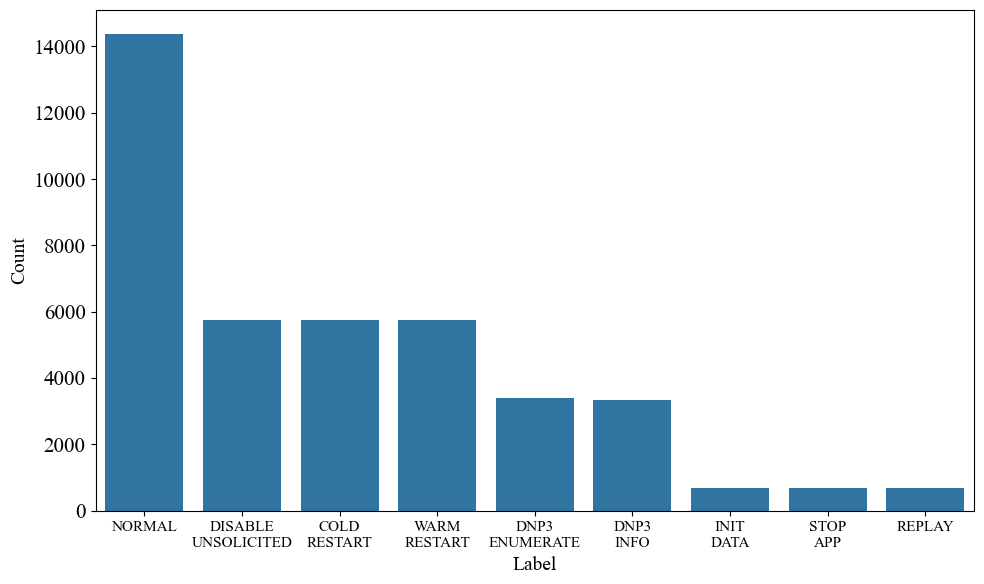

In [4]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font family and size
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif", "serif"]
mpl.rcParams["font.size"] = 12  # Adjust per Springer guidelines
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11

# Optional: PDF/LaTeX text rendering for enhanced output
mpl.rcParams["text.usetex"] = False

df = pd.read_csv(
    r"C:\Users\Viper\Desktop\thesis_code\data\Custom_DNP3_Parser\combined_120_timeout.csv"
)



df.columns = [c.strip() for c in df.columns]



plt.figure(figsize=(10, 6))



# Use a colorblind-friendly palette


# palette = sns.color_palette("muted")



# Plot countplot with labels ordered by frequency


ax = sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)



# Title and axis labels with appropriate font sizes


# ax.set_title("Distribution of Labels in Dataset", fontsize=16, weight="bold")


ax.set_xlabel("Label", fontsize=14)


ax.set_ylabel("Count", fontsize=14)


warped_labels = [
    "\n".join(label.split("_")) for label in df["Label"].value_counts().index
]


ax.set_xticklabels(warped_labels)



# Rotate x-ticks for readability, adjust alignment


# plt.xticks(rotation=30, ha="right", fontsize=12)


plt.yticks(fontsize=15)



plt.tight_layout()



# Save figure with high resolution suitable for publication


plt.savefig("dnp3_label_distribution.pdf", dpi=300)



plt.show()

In [27]:
import numpy as np

arr = bytearray(b"\x05d\x0b\xc4\x0c\x00\x01\x00.\xc5\xce\xcd\x01<\x02\x06\x06\xeb")
arr = np.frombuffer(arr, dtype=np.uint8)
arr

array([  5, 100,  11, 196,  12,   0,   1,   0,  46, 197, 206, 205,   1,
        60,   2,   6,   6, 235], dtype=uint8)

In [28]:
freq_arr = np.zeros(256, dtype=np.float32)
for byte in arr:
    freq_arr[byte] += 1
freq_arr.astype(np.uint8)

array([2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8)

In [30]:
normalized_freq_arr = freq_arr / freq_arr.max() * 255
normalized_freq_arr.astype(np.uint8)

array([255, 255, 127,   0,   0, 127, 255,   0,   0,   0,   0, 127, 127,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0, 127,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0, 127,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   